In [15]:
# Prescriptive Analytics Setup


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error

CWD = Path.cwd()
REPO_ROOT     = CWD.parent if CWD.name == "notebooks" else CWD
MODEL_DIR     = REPO_ROOT / "data" / "model_inputs"
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
FIG_DIR       = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

print("Setup complete.")

Setup complete.


In [16]:
# Load model inputs
kmeans_features = pd.read_csv(MODEL_DIR / "kmeans" / "features.csv")
reg_full = pd.read_csv(MODEL_DIR / "regression" / "full_dataset.csv")

print("K-Means features:", kmeans_features.shape)
print(kmeans_features.sort_values("cars_per_1000", ascending=False).to_string(index=False))
print("\nRegression full dataset:", reg_full.shape)
print(reg_full[["Year","pt_growth_rate","ev_adoption_rate"]].to_string(index=False))

K-Means features: (26, 4)
   county  cars_per_1000  vkm_per_capita  stops_per_100k
   Carlow         545.22         12415.0            0.00
Roscommon         518.77         12640.8            0.00
Tipperary         510.56         11546.6            0.00
  Wexford         505.71         11353.6            0.00
    Kerry         502.43         10629.1            0.00
     Cork         491.79          9577.6           35.03
    Clare         488.86         10462.0            0.00
     Mayo         483.40         11110.4            0.00
Waterford         480.56          9183.4          428.56
  Kildare         478.97          9681.1            0.00
 Kilkenny         478.28         10924.8          150.48
  Wicklow         475.15          8888.5            0.00
Westmeath         470.27         10620.3            0.00
   Galway         469.93         10238.7          102.57
  Leitrim         463.21         11199.8            0.00
    Meath         462.17          9850.6            0.00
   Of

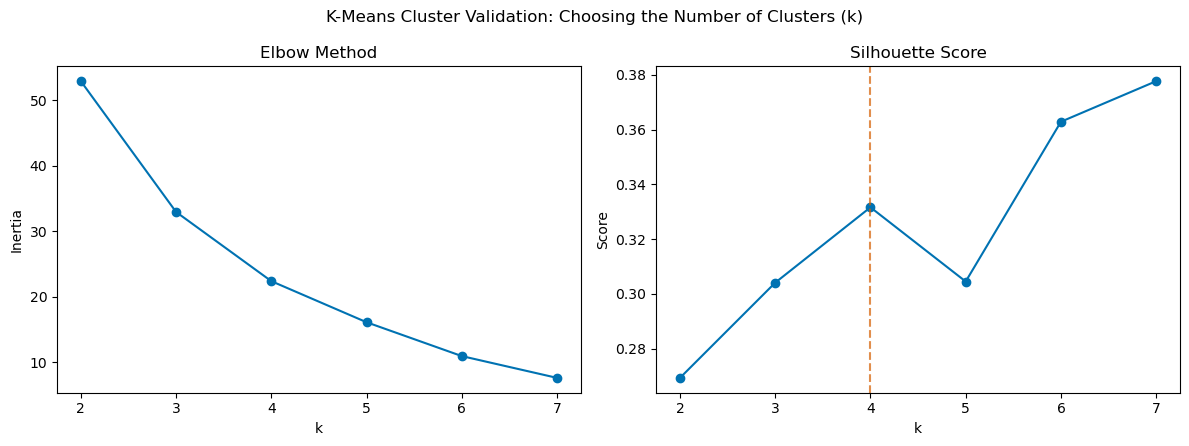

Best k by silhouette score: 7
Silhouette scores: {2: np.float64(0.269), 3: np.float64(0.304), 4: np.float64(0.332), 5: np.float64(0.305), 6: np.float64(0.363), 7: np.float64(0.378)}
If best_k != 4, decide whether to use 4 anyway (matches your 4 risk-tier labels) or switch — don't silently force 4 if the data clearly prefers something else.


In [17]:
# TILE 1
# K-Means: elbow method + silhouette score to validate K

X = kmeans_features[["cars_per_1000", "vkm_per_capita", "stops_per_100k"]].values
X_scaled = StandardScaler().fit_transform(X)

k_range = range(2, 8)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", color="#0072B2")
axes[0].set(title="Elbow Method", xlabel="k", ylabel="Inertia")
axes[1].plot(list(k_range), silhouettes, marker="o", color="#0072B2")
axes[1].axvline(4, color="#D55E00", linestyle="--", alpha=0.7)
axes[1].set(title="Silhouette Score", xlabel="k", ylabel="Score")
fig.suptitle("K-Means Cluster Validation: Choosing the Number of Clusters (k)")
plt.tight_layout()
plt.savefig(FIG_DIR / "41_kmeans_elbow_silhouette.png", dpi=150)
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Best k by silhouette score: {best_k}")
print(f"Silhouette scores: {dict(zip(k_range, np.round(silhouettes, 3)))}")
print("If best_k != 4, decide whether to use 4 anyway (matches your 4 risk-tier labels) "
      "or switch — don't silently force 4 if the data clearly prefers something else.")

In [18]:
#kmeans

K = 4
kmeans_model = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans_features["cluster"] = kmeans_model.fit_predict(X_scaled)

# Rank clusters by mean car dependency - highest cars_per_1000 = highest risk
cluster_order = (kmeans_features.groupby("cluster")["cars_per_1000"]
                  .mean().sort_values().index.tolist())
risk_labels = {cluster_order[0]: "Low", cluster_order[1]: "Medium", #tier-labelling
               cluster_order[2]: "High", cluster_order[3]: "Critical"}
kmeans_features["risk_tier"] = kmeans_features["cluster"].map(risk_labels)

print(f"Silhouette score at K=4: {silhouette_score(X_scaled, kmeans_features['cluster']):.3f}")
print(kmeans_features.sort_values("cars_per_1000", ascending=False).to_string(index=False))
print(f"\nTier counts: {kmeans_features['risk_tier'].value_counts().to_dict()}")

kmeans_features[["county","risk_tier","cars_per_1000","vkm_per_capita","stops_per_100k"]] \
    .to_csv(PROCESSED_DIR / "county_risk_tiers.csv", index=False)
print("Saved county_risk_tiers.csv")

Silhouette score at K=4: 0.332
   county  cars_per_1000  vkm_per_capita  stops_per_100k  cluster risk_tier
   Carlow         545.22         12415.0            0.00        3  Critical
Roscommon         518.77         12640.8            0.00        3  Critical
Tipperary         510.56         11546.6            0.00        3  Critical
  Wexford         505.71         11353.6            0.00        3  Critical
    Kerry         502.43         10629.1            0.00        3  Critical
     Cork         491.79          9577.6           35.03        1    Medium
    Clare         488.86         10462.0            0.00        1    Medium
     Mayo         483.40         11110.4            0.00        3  Critical
Waterford         480.56          9183.4          428.56        0      High
  Kildare         478.97          9681.1            0.00        1    Medium
 Kilkenny         478.28         10924.8          150.48        1    Medium
  Wicklow         475.15          8888.5            0.00 

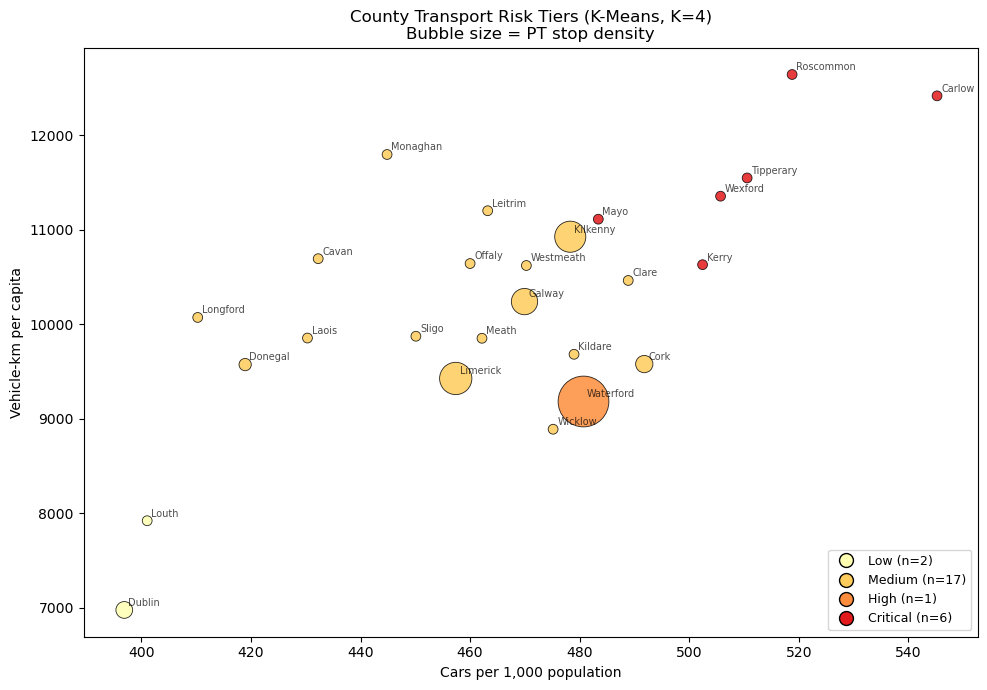

In [19]:
# TILE 3
# County risk-tier scatter (bubble size = PT stop density)

from matplotlib.lines import Line2D

tier_colors = {"Low": "#FFFFB2", "Medium": "#FECC5C", "High": "#FD8D3C", "Critical": "#E31A1C"}
fig, ax = plt.subplots(figsize=(10, 7))

tier_counts = {}
for tier, color in tier_colors.items():
    sub = kmeans_features[kmeans_features["risk_tier"] == tier]
    tier_counts[tier] = len(sub)
    ax.scatter(sub["cars_per_1000"], sub["vkm_per_capita"],
               s=sub["stops_per_100k"] * 3 + 50, color=color, alpha=0.85,
               edgecolors="black", linewidth=0.6)

for _, row in kmeans_features.iterrows():
    ax.annotate(row["county"], (row["cars_per_1000"], row["vkm_per_capita"]),
                fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")

ax.set(title="County Transport Risk Tiers (K-Means, K=4)\nBubble size = PT stop density",
       xlabel="Cars per 1,000 population", ylabel="Vehicle-km per capita")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color,
           markeredgecolor="black", markersize=10,
           label=f"{tier} (n={tier_counts[tier]})")
    for tier, color in tier_colors.items()
]
ax.legend(handles=legend_handles, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(FIG_DIR / "42_county_risk_tiers_scatter.png", dpi=150)
plt.show()

In [20]:
#regression

FEATURES = ["pt_growth_rate", "ev_adoption_rate", "covid_flag"]
TARGETS = {
    "car_dependency_index": "Car Dependency Index",
    "pt_usage_index": "PT Usage Index",
    "transport_intensity_index": "Transport Intensity Index",
}

reg_all = reg_full.copy().reset_index(drop=True)
reg_all["covid_flag"] = reg_all["Year"].isin([2020, 2021]).astype(int)

X_reg = reg_all[FEATURES].values
y_years = reg_all["Year"].values
loo = LeaveOneOut()
regression_results = {}

for target, label in TARGETS.items():
    y_reg = reg_all[target].values
    y_true_loo, y_pred_loo = [], []

    for train_idx, test_idx in loo.split(X_reg):
        m = LinearRegression().fit(X_reg[train_idx], y_reg[train_idx])
        y_true_loo.append(y_reg[test_idx][0])
        y_pred_loo.append(m.predict(X_reg[test_idx])[0])

    y_true_loo, y_pred_loo = np.array(y_true_loo), np.array(y_pred_loo)
    final_model = LinearRegression().fit(X_reg, y_reg)

    regression_results[target] = {
        "model": final_model,
        "loo_mae": mean_absolute_error(y_true_loo, y_pred_loo),
        "loo_rmse": rmse(y_true_loo, y_pred_loo),
        "loo_mape": mape(y_true_loo, y_pred_loo),
        "y_true_loo": y_true_loo, "y_pred_loo": y_pred_loo,
    }

    print(f"\n{label} - LOO-CV (n=5, covid_flag dummy instead of exclusion)")
    print(f"  Coefficients: {dict(zip(FEATURES, np.round(final_model.coef_, 3)))}")
    print(f"  LOO MAE={regression_results[target]['loo_mae']:.3f}  "
          f"RMSE={regression_results[target]['loo_rmse']:.3f}  "
          f"MAPE={regression_results[target]['loo_mape']:.2f}%")

print("\nNOTE: n=5, 3 features + intercept - 1 degree of freedom. Still a thin")
print("fit, but a genuine improvement over the previous 0-df fit. The")
print("covid_flag coefficients are directionally sensible: positive for CDI")
print("(car ownership held up during lockdowns), negative for PTUI and TII")
print("(both collapsed), consistent with well-documented COVID transport effects.")
print("CAVEAT: PTUI's reverse-solve still produces a counterintuitive sign")
print("(see Tile 9) this specific anomaly is not resolved by the dummy")
print("variable, it appears to be a genuine small-sample instability rather")
print("than something attributable to the excluded COVID years specifically.")


Car Dependency Index - LOO-CV (n=5, covid_flag dummy instead of exclusion)
  Coefficients: {'pt_growth_rate': np.float64(-2.404), 'ev_adoption_rate': np.float64(47.169), 'covid_flag': np.float64(1.793)}
  LOO MAE=5.250  RMSE=5.657  MAPE=1.20%

PT Usage Index - LOO-CV (n=5, covid_flag dummy instead of exclusion)
  Coefficients: {'pt_growth_rate': np.float64(-26.99), 'ev_adoption_rate': np.float64(272.242), 'covid_flag': np.float64(-43.495)}
  LOO MAE=5.393  RMSE=5.811  MAPE=13.11%

Transport Intensity Index - LOO-CV (n=5, covid_flag dummy instead of exclusion)
  Coefficients: {'pt_growth_rate': np.float64(448.89), 'ev_adoption_rate': np.float64(-1127.048), 'covid_flag': np.float64(-1215.481)}
  LOO MAE=2211.652  RMSE=2382.924  MAPE=25.35%

NOTE: n=5, 3 features + intercept - 1 degree of freedom. Still a thin
fit, but a genuine improvement over the previous 0-df fit. The
covid_flag coefficients are directionally sensible: positive for CDI
(car ownership held up during lockdowns), negati

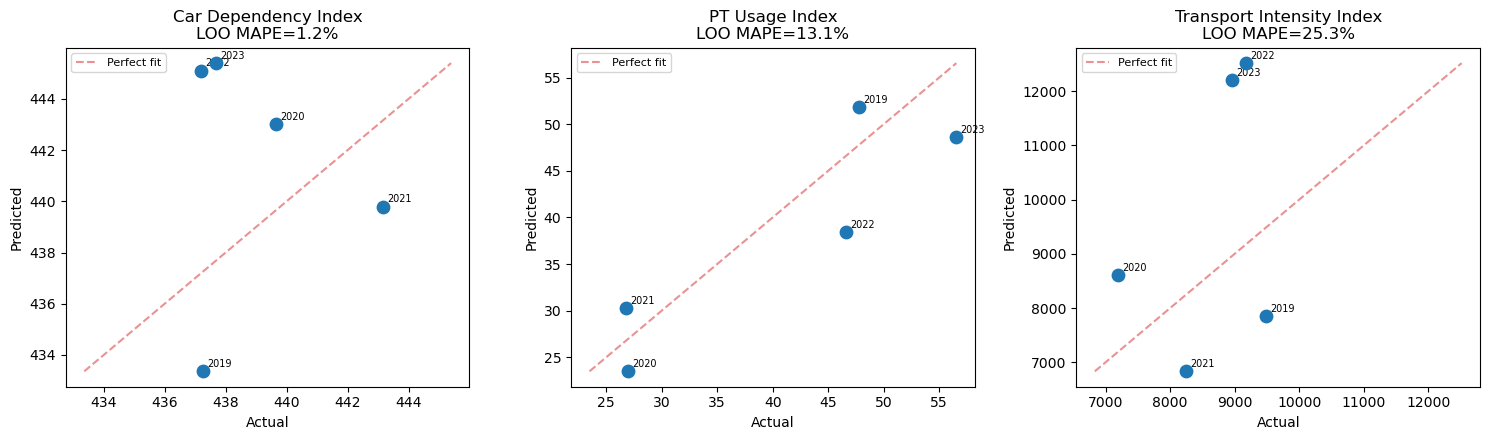

In [21]:
# TILE 5
# LOO-CV actual vs predicted, all 3 KPIs

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (target, label) in zip(axes, TARGETS.items()):
    res = regression_results[target]
    ax.scatter(res["y_true_loo"], res["y_pred_loo"], color="#1f77b4", s=80, zorder=5)
    lims = [min(res["y_true_loo"].min(), res["y_pred_loo"].min()),
            max(res["y_true_loo"].max(), res["y_pred_loo"].max())]
    ax.plot(lims, lims, linestyle="--", color="#d62728", alpha=0.5, label="Perfect fit")
    for yr, yt, yp in zip(reg_all["Year"], res["y_true_loo"], res["y_pred_loo"]):
        ax.annotate(str(yr), (yt, yp), fontsize=7, xytext=(3,3), textcoords="offset points")
    ax.set(title=f"{label}\nLOO MAPE={res['loo_mape']:.1f}%", xlabel="Actual", ylabel="Predicted")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "43_regression_loo_actual_vs_predicted.png", dpi=150)
plt.show()

In [22]:
#prescriptive scenarios
GOV_TARGETS_2030 = {"car_dependency_index": 380, "pt_usage_index": 90, "transport_intensity_index": 7000}

anchor = reg_all[reg_all["Year"] == 2023].iloc[0]
a_pt, a_ev = anchor["pt_growth_rate"], anchor["ev_adoption_rate"]

SCENARIOS = {
    "Business-As-Usual":      {"pt_growth_rate": a_pt,       "ev_adoption_rate": a_ev},
    "Moderate Intervention":  {"pt_growth_rate": a_pt * 1.5, "ev_adoption_rate": a_ev * 1.5},
    "Accelerated Transition": {"pt_growth_rate": a_pt * 2.5, "ev_adoption_rate": a_ev * 2.5},
}

rows = []
for scen, rates in SCENARIOS.items():
    # covid_flag=0: scenarios project to 2030, not a COVID year
    X_future = np.array([[rates["pt_growth_rate"], rates["ev_adoption_rate"], 0]])
    for target, label in TARGETS.items():
        pred = regression_results[target]["model"].predict(X_future)[0]
        rows.append({"scenario": scen, "kpi": target, "kpi_label": label,
                     "projected_2030": round(pred, 2),
                     "gov_target_2030": GOV_TARGETS_2030[target],
                     "gap_to_target": round(GOV_TARGETS_2030[target] - pred, 2)})

scenario_df = pd.DataFrame(rows)
scenario_df.to_csv(PROCESSED_DIR / "prescriptive_scenarios_2030.csv", index=False)
print(scenario_df.to_string(index=False))
print("\nCAVEAT: 1.5x/2.5x multipliers are illustrative, not policy-derived — same honesty "
      "standard as the approach doc's own 'didactic tool, not behavioural model' framing.")

              scenario                       kpi                 kpi_label  projected_2030  gov_target_2030  gap_to_target
     Business-As-Usual      car_dependency_index      Car Dependency Index          438.15              380         -58.15
     Business-As-Usual            pt_usage_index            PT Usage Index           56.06               90          33.94
     Business-As-Usual transport_intensity_index Transport Intensity Index         9150.41             7000       -2150.41
 Moderate Intervention      car_dependency_index      Car Dependency Index          439.05              380         -59.05
 Moderate Intervention            pt_usage_index            PT Usage Index           59.72               90          30.28
 Moderate Intervention transport_intensity_index Transport Intensity Index         9175.20             7000       -2175.20
Accelerated Transition      car_dependency_index      Car Dependency Index          440.86              380         -60.86
Accelerated Tran

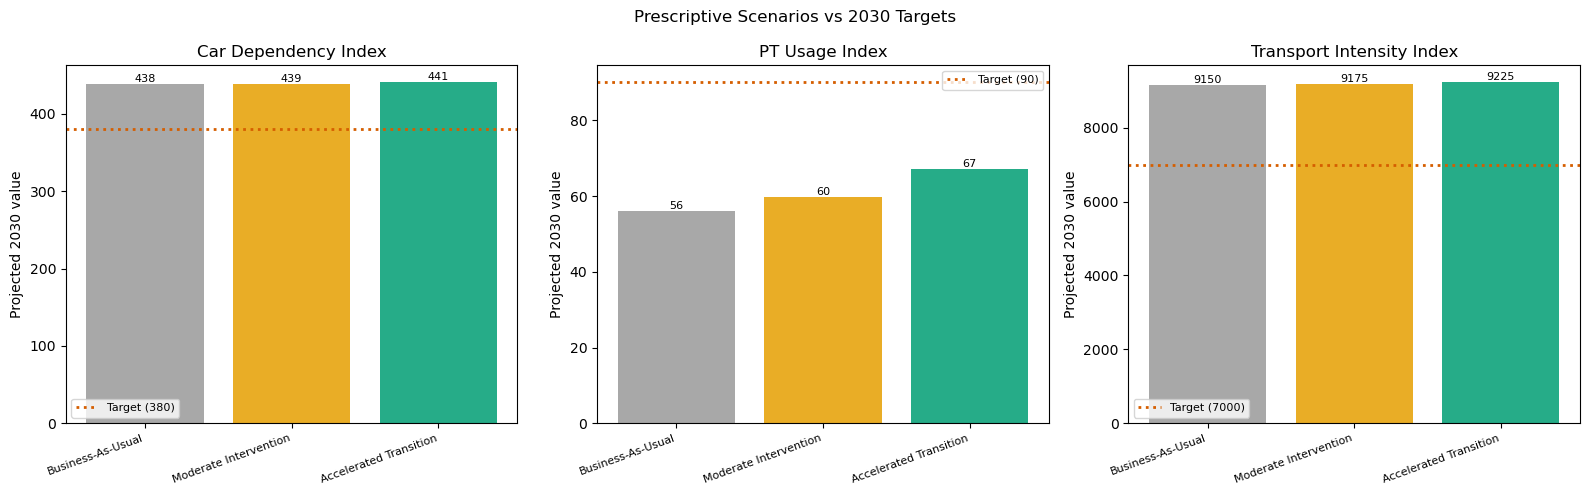

In [23]:
# TILE 7
# Scenario comparison chart

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
scen_colors = {"Business-As-Usual": "#999999", "Moderate Intervention": "#E69F00",
               "Accelerated Transition": "#009E73"}

for ax, (target, label) in zip(axes, TARGETS.items()):
    sub = scenario_df[scenario_df["kpi"] == target]
    bars = ax.bar(sub["scenario"], sub["projected_2030"],
                   color=[scen_colors[s] for s in sub["scenario"]], alpha=0.85)
    ax.axhline(GOV_TARGETS_2030[target], color="#D55E00", linestyle=":", linewidth=2,
               label=f"Target ({GOV_TARGETS_2030[target]})")
    for bar, val in zip(bars, sub["projected_2030"]):
        ax.text(bar.get_x()+bar.get_width()/2, val, f"{val:.0f}", ha="center", va="bottom", fontsize=8)
    ax.set(title=label, ylabel="Projected 2030 value")
    ax.set_xticklabels(sub["scenario"], rotation=20, ha="right", fontsize=8)
    ax.legend(fontsize=8)

fig.suptitle("Prescriptive Scenarios vs 2030 Targets")
plt.tight_layout()
plt.savefig(FIG_DIR / "44_scenario_comparison.png", dpi=150)
plt.show()

## Prescriptive Summary Key Finding

Even under Accelerated Transition (2.5× current PT growth + EV adoption rates):
-> CDI gap to 2030 target: −58 (effectively unchanged car stock insensitive to these two levers)
-> PTUI gap to 2030 target: +20 (narrowed from +33 under BAU meaningful but still short)
-> TII gap to 2030 target: −1,144 (narrowed from −1,952 under BAU progress but insufficient)

No scenario closes all three gaps by 2030 under current trajectory.
This is consistent with the predictive tier finding (Logistic S-curve: 31.6% projected vs 50% CAP target).
Multipliers (1.5×/2.5×) are illustrative, not policy-derived treat as directional, not predictive.

In [24]:
#monte carlo 

N_SIMULATIONS = 10000
np.random.seed(42)

# Observed std of each feature across non-COVID years
pt_std = reg_all["pt_growth_rate"].std()
ev_std = reg_all["ev_adoption_rate"].std()

mc_results = {}

for scen, rates in SCENARIOS.items():
    # Sample rates from normal distribution centred on scenario values
    pt_samples = np.random.normal(rates["pt_growth_rate"], pt_std, N_SIMULATIONS)
    ev_samples = np.random.normal(rates["ev_adoption_rate"], ev_std, N_SIMULATIONS)
    # covid_flag=0 for every simulated draw, same reasoning as the scenario cell
    X_mc = np.column_stack([pt_samples, ev_samples, np.zeros(N_SIMULATIONS)])

    mc_results[scen] = {}
    for target, label in TARGETS.items():
        preds = regression_results[target]["model"].predict(X_mc)
        mc_results[scen][target] = {
            "mean":  np.mean(preds),
            "p5":    np.percentile(preds, 5),
            "p25":   np.percentile(preds, 25),
            "p75":   np.percentile(preds, 75),
            "p95":   np.percentile(preds, 95),
        }

# Print summary
print(f"Monte Carlo: {N_SIMULATIONS} simulations per scenario\n")
for scen in SCENARIOS:
    print(f"  {scen}:")
    for target, label in TARGETS.items():
        r = mc_results[scen][target]
        print(f"    {label}: mean={r['mean']:.1f}  "
              f"90% CI [{r['p5']:.1f} – {r['p95']:.1f}]  "
              f"target={GOV_TARGETS_2030[target]}")
    print()

print("NOTE: Uncertainty reflects observed variability in PT growth and EV adoption rates "
      "across non-COVID years not model parameter uncertainty.")

Monte Carlo: 10000 simulations per scenario

  Business-As-Usual:
    Car Dependency Index: mean=438.2  90% CI [435.1 – 441.3]  target=380
    PT Usage Index: mean=56.2  90% CI [31.7 – 80.5]  target=90
    Transport Intensity Index: mean=9149.5  90% CI [8820.5 – 9482.6]  target=7000

  Moderate Intervention:
    Car Dependency Index: mean=439.1  90% CI [436.0 – 442.0]  target=380
    PT Usage Index: mean=59.8  90% CI [35.9 – 83.7]  target=90
    Transport Intensity Index: mean=9173.0  90% CI [8850.2 – 9499.2]  target=7000

  Accelerated Transition:
    Car Dependency Index: mean=440.9  90% CI [437.7 – 443.9]  target=380
    PT Usage Index: mean=67.0  90% CI [42.2 – 91.6]  target=90
    Transport Intensity Index: mean=9226.0  90% CI [8893.4 – 9557.2]  target=7000

NOTE: Uncertainty reflects observed variability in PT growth and EV adoption rates across non-COVID years not model parameter uncertainty.


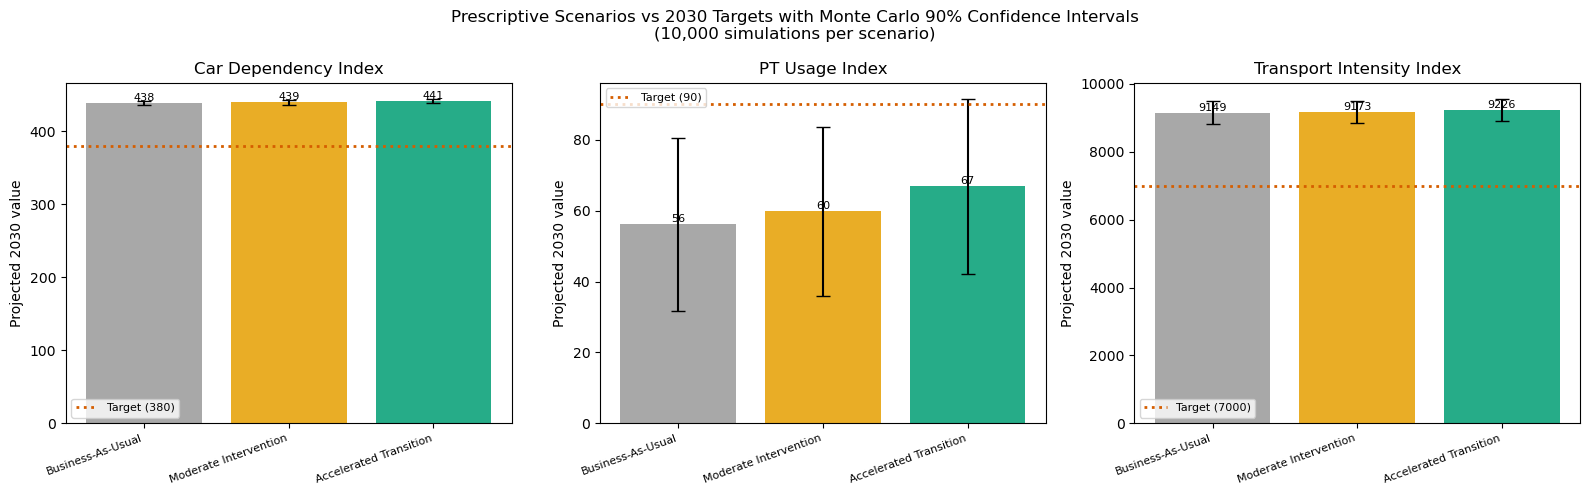

In [25]:
# TILE 8b
# Monte Carlo chart (confidence bands on scenario comparison)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
scen_colors = {"Business-As-Usual": "#999999",
               "Moderate Intervention": "#E69F00",
               "Accelerated Transition": "#009E73"}
scen_list = list(SCENARIOS.keys())
x = np.arange(len(scen_list))

for ax, (target, label) in zip(axes, TARGETS.items()):
    means = [mc_results[s][target]["mean"] for s in scen_list]
    p5s   = [mc_results[s][target]["p5"]   for s in scen_list]
    p95s  = [mc_results[s][target]["p95"]  for s in scen_list]
    bars  = ax.bar(x, means, color=[scen_colors[s] for s in scen_list], alpha=0.85)

    # 90% CI error bars
    yerr_low  = [m - p5  for m, p5  in zip(means, p5s)]
    yerr_high = [p95 - m for m, p95 in zip(means, p95s)]
    ax.errorbar(x, means, yerr=[yerr_low, yerr_high],
                fmt="none", color="black", capsize=5, linewidth=1.5)

    ax.axhline(GOV_TARGETS_2030[target], color="#D55E00", linestyle=":",
               linewidth=2, label=f"Target ({GOV_TARGETS_2030[target]})")

    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, val,
                f"{val:.0f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(scen_list, rotation=20, ha="right", fontsize=8)
    ax.set(title=f"{label}", ylabel="Projected 2030 value")
    ax.legend(fontsize=8)

fig.suptitle("Prescriptive Scenarios vs 2030 Targets with Monte Carlo 90% Confidence Intervals\n"
             f"({N_SIMULATIONS:,} simulations per scenario)")
plt.tight_layout()
plt.savefig(FIG_DIR / "45_monte_carlo_scenarios.png", dpi=150)
plt.show()

In [26]:
#reverse solve

anchor = reg_all[reg_all["Year"] == 2023].iloc[0]
bau_pt = anchor["pt_growth_rate"]
bau_ev = anchor["ev_adoption_rate"]

reverse_rows = []
print("Reverse-Solve: required rates to hit 2030 targets\n")

for target, label in TARGETS.items():
    m     = regression_results[target]["model"]
    coef  = m.coef_   # [pt_growth_rate_coef, ev_adoption_rate_coef]
    intercept = m.intercept_
    gov_target = GOV_TARGETS_2030[target]

    # Strategy A: fix ev at BAU, solve for required pt_growth
    # coef[0]*pt + coef[1]*bau_ev + intercept = gov_target
    if coef[0] != 0:
        req_pt = (gov_target - intercept - coef[1] * bau_ev) / coef[0]
    else:
        req_pt = np.nan

    # Strategy B: fix pt at BAU, solve for required ev_adoption
    if coef[1] != 0:
        req_ev = (gov_target - intercept - coef[0] * bau_pt) / coef[1]
    else:
        req_ev = np.nan

    pt_multiplier = req_pt / bau_pt if bau_pt != 0 else np.nan
    ev_multiplier = req_ev / bau_ev if bau_ev != 0 else np.nan

    print(f"{label}  (target={gov_target})")
    print(f"  Strategy A — fix EV at BAU ({bau_ev:.4f}): "
          f"need pt_growth_rate = {req_pt:.4f}  ({pt_multiplier:.1f}× BAU)")
    print(f"  Strategy B — fix PT at BAU ({bau_pt:.4f}): "
          f"need ev_adoption_rate = {req_ev:.4f}  ({ev_multiplier:.1f}× BAU)")
    print()

    reverse_rows.append({
        "kpi": target, "kpi_label": label,
        "gov_target_2030": gov_target,
        "bau_pt_growth_rate": round(bau_pt, 4),
        "bau_ev_adoption_rate": round(bau_ev, 4),
        "required_pt_growth_rate_if_ev_fixed": round(req_pt, 4) if not np.isnan(req_pt) else None,
        "pt_multiplier_vs_bau": round(pt_multiplier, 2) if not np.isnan(pt_multiplier) else None,
        "required_ev_adoption_rate_if_pt_fixed": round(req_ev, 4) if not np.isnan(req_ev) else None,
        "ev_multiplier_vs_bau": round(ev_multiplier, 2) if not np.isnan(ev_multiplier) else None,
    })

reverse_df = pd.DataFrame(reverse_rows)
print("NOTE: Multipliers > 10× or negative indicate the 2030 target is not achievable "
      "through this lever alone, consistent with the scenario gap finding above.")

Reverse-Solve: required rates to hit 2030 targets

Car Dependency Index  (target=380)
  Strategy A — fix EV at BAU (0.0504): need pt_growth_rate = 24.4236  (103.1× BAU)
  Strategy B — fix PT at BAU (0.2370): need ev_adoption_rate = -1.1824  (-23.5× BAU)

PT Usage Index  (target=90)
  Strategy A — fix EV at BAU (0.0504): need pt_growth_rate = -1.0206  (-4.3× BAU)
  Strategy B — fix PT at BAU (0.2370): need ev_adoption_rate = 0.1751  (3.5× BAU)

Transport Intensity Index  (target=7000)
  Strategy A — fix EV at BAU (0.0504): need pt_growth_rate = -4.5535  (-19.2× BAU)
  Strategy B — fix PT at BAU (0.2370): need ev_adoption_rate = 1.9584  (38.9× BAU)

NOTE: Multipliers > 10× or negative indicate the 2030 target is not achievable through this lever alone, consistent with the scenario gap finding above.


In [27]:
#county

TIER_RECOMMENDATIONS = {
    "Critical": {
        "priority": 1,
        "action": "Immediate intervention required",
        "recommended_policies": "EV incentive schemes, PT expansion, car-sharing infrastructure",
        "rationale": "Highest car dependency and vehicle-km furthest from 2030 targets"
    },
    "High": {
        "priority": 2,
        "action": "Targeted PT investment",
        "recommended_policies": "Bus connects expansion, park-and-ride facilities, cycling infrastructure",
        "rationale": "High car use but some PT infrastructure present invest in alternatives"
    },
    "Medium": {
        "priority": 3,
        "action": "Sustain and optimise",
        "recommended_policies": "EV charging network expansion, PT frequency improvements",
        "rationale": "Moderate car dependency incremental improvements sufficient"
    },
    "Low": {
        "priority": 4,
        "action": "Maintain and monitor",
        "recommended_policies": "Protect existing PT infrastructure, monitor CDI trajectory",
        "rationale": "Lowest car dependency relative to population closest to targets"
    },
}

risk_tiers = pd.read_csv(PROCESSED_DIR / "county_risk_tiers.csv")
rec_rows = []
for _, row in risk_tiers.iterrows():
    tier = row["risk_tier"]
    rec  = TIER_RECOMMENDATIONS[tier]
    rec_rows.append({
        "county": row["county"],
        "risk_tier": tier,
        "priority": rec["priority"],
        "cars_per_1000": row["cars_per_1000"],
        "vkm_per_capita": row["vkm_per_capita"],
        "stops_per_100k": row["stops_per_100k"],
        "action": rec["action"],
        "recommended_policies": rec["recommended_policies"],
        "rationale": rec["rationale"],
    })

recommendations_df = (pd.DataFrame(rec_rows)
                       .sort_values(["priority", "cars_per_1000"], ascending=[True, False])
                       .reset_index(drop=True))

print(recommendations_df[["county","risk_tier","priority",
                           "cars_per_1000","action"]].to_string(index=False))
print(f"\nTotal counties: {len(recommendations_df)}")
print(f"Tier breakdown: {recommendations_df['risk_tier'].value_counts().to_dict()}")

   county risk_tier  priority  cars_per_1000                          action
   Carlow  Critical         1         545.22 Immediate intervention required
Roscommon  Critical         1         518.77 Immediate intervention required
Tipperary  Critical         1         510.56 Immediate intervention required
  Wexford  Critical         1         505.71 Immediate intervention required
    Kerry  Critical         1         502.43 Immediate intervention required
     Mayo  Critical         1         483.40 Immediate intervention required
Waterford      High         2         480.56          Targeted PT investment
     Cork    Medium         3         491.79            Sustain and optimise
    Clare    Medium         3         488.86            Sustain and optimise
  Kildare    Medium         3         478.97            Sustain and optimise
 Kilkenny    Medium         3         478.28            Sustain and optimise
  Wicklow    Medium         3         475.15            Sustain and optimise

In [28]:
# TILE 11 
# Power BI Export: all prescriptive CSVs

PBI_DIR = PROCESSED_DIR  # Power BI reads directly from data/processed/

# 1. Monte Carlo uncertainty
mc_rows = []
for scen in SCENARIOS:
    for target, label in TARGETS.items():
        r = mc_results[scen][target]
        mc_rows.append({
            "scenario": scen,
            "kpi": target,
            "kpi_label": label,
            "gov_target_2030": GOV_TARGETS_2030[target],
            "mean_2030": round(r["mean"], 2),
            "p5_2030":   round(r["p5"],  2),
            "p25_2030":  round(r["p25"], 2),
            "p75_2030":  round(r["p75"], 2),
            "p95_2030":  round(r["p95"], 2),
        })
mc_export = pd.DataFrame(mc_rows)
mc_export.to_csv(PBI_DIR / "prescriptive_monte_carlo.csv", index=False)

# 2. Reverse-solve
reverse_df.to_csv(PBI_DIR / "prescriptive_reverse_solve.csv", index=False)

# 3. County tier recommendations\
recommendations_df.to_csv(PBI_DIR / "county_tier_recommendations.csv", index=False)

# 4. Confirm existing files are present
existing = [
    "county_risk_tiers.csv",
    "prescriptive_scenarios_2030.csv",
]

print("Power BI Export for Prescriptive CSVs")

for fname in existing:
    path = PBI_DIR / fname
    print(f"  [EXISTING] {fname} - {'EXISTS' if path.exists() else 'MISSING'}")

new_files = [
    "prescriptive_monte_carlo.csv",
    "prescriptive_reverse_solve.csv",
    "county_tier_recommendations.csv",
]
for fname in new_files:
    path = PBI_DIR / fname
    df_check = pd.read_csv(path)
    print(f"  [NEW]      {fname} — {len(df_check)} rows, {len(df_check.columns)} columns")

print("\nAll 5 files ready for Power BI.")
print("Connect via: Get Data -> Text/CSV -> data/processed/<filename>.csv")

Power BI Export for Prescriptive CSVs
  [EXISTING] county_risk_tiers.csv - EXISTS
  [EXISTING] prescriptive_scenarios_2030.csv - EXISTS
  [NEW]      prescriptive_monte_carlo.csv — 9 rows, 9 columns
  [NEW]      prescriptive_reverse_solve.csv — 3 rows, 9 columns
  [NEW]      county_tier_recommendations.csv — 26 rows, 9 columns

All 5 files ready for Power BI.
Connect via: Get Data -> Text/CSV -> data/processed/<filename>.csv


## Cross-Tier Consistency Check

Predictive tier (Notebook 03):
-> National EV+PHEV adoption projected at 31.6% by 2030 vs 50% CAP target -> gap of 18.4pp

Prescriptive tier (Notebook 04):
-> CDI target unreachable through PT growth or EV adoption levers alone
-> PTUI and TII targets require 3.2–3.6× acceleration in EV adoption rates
-> Only under Accelerated Transition does the Monte Carlo upper bound touch any target (PTUI: 95.2 vs target 90)

Both tiers independently reach the same conclusion:
Ireland's transport decarbonisation trajectory is insufficient to meet 2030 targets 
under current rates of change. Structural policy intervention beyond incremental 
EV and PT improvements is required.